# Project AIM

In [69]:
"""The aim of this project is to predict medical insurance charges based on factors such as age, gender, BMI, smoking habits, number of children, and region using Machine Learning techniques.

This project involves data analysis, data visualization, feature engineering, model building, and model evaluation to identify the factors that most influence insurance costs and to build an accurate prediction model."""

'The aim of this project is to predict medical insurance charges based on factors such as age, gender, BMI, smoking habits, number of children, and region using Machine Learning techniques.\n\nThis project involves data analysis, data visualization, feature engineering, model building, and model evaluation to identify the factors that most influence insurance costs and to build an accurate prediction model.'

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('insurance.csv')
dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [5]:
dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
dataset.shape

(1338, 7)

In [7]:
dataset.isnull().sum()  

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
dataset.duplicated().sum()

np.int64(1)

In [9]:
dataset = dataset.drop_duplicates()
dataset.duplicated().sum()

np.int64(0)

In [10]:
dataset.columns.duplicated().sum()

np.int64(0)

# EDA

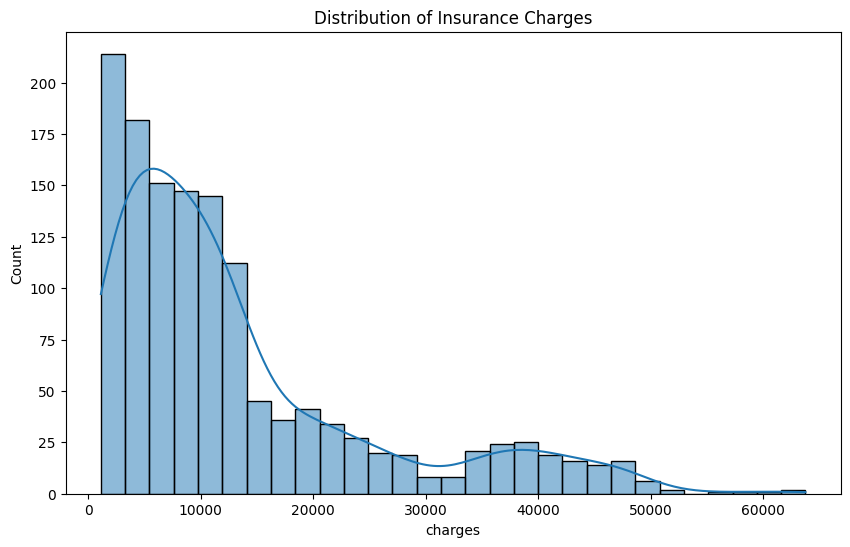

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(dataset['charges'], kde=True)
plt.title('Distribution of Insurance Charges')
plt.show()

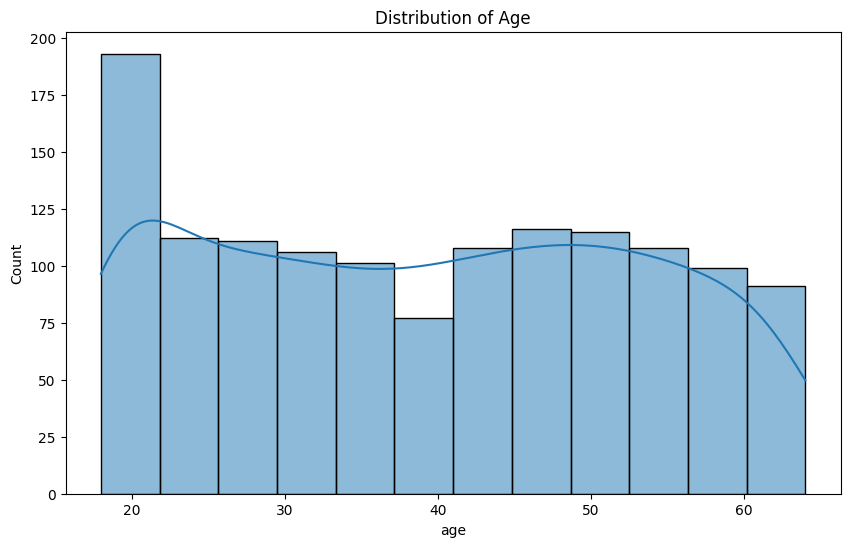

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(dataset['age'], kde=True)
plt.title('Distribution of Age')
plt.show()

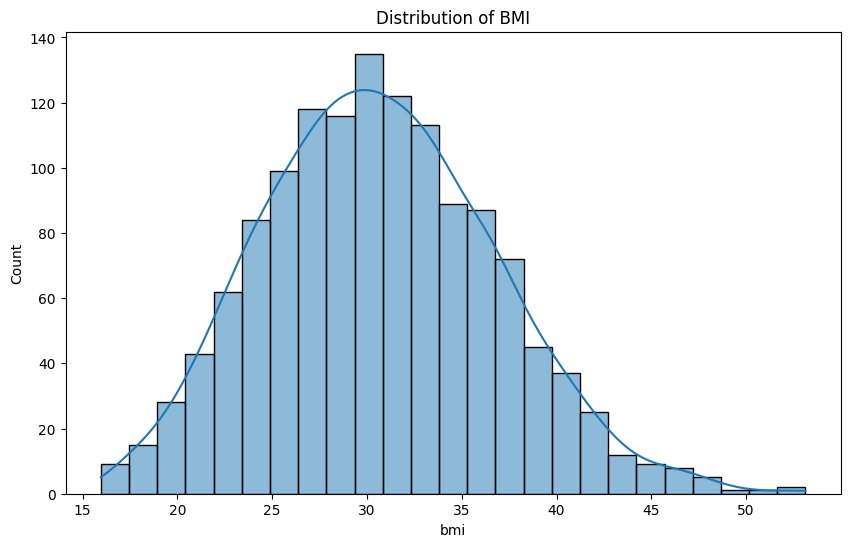

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(dataset['bmi'], kde=True)
plt.title('Distribution of BMI')
plt.show()  

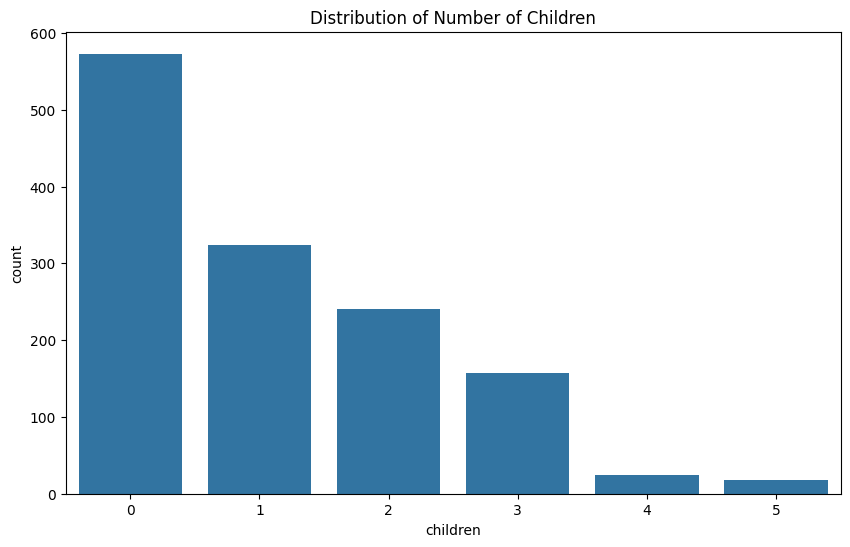

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x='children', data=dataset)
plt.title('Distribution of Number of Children')
plt.show()

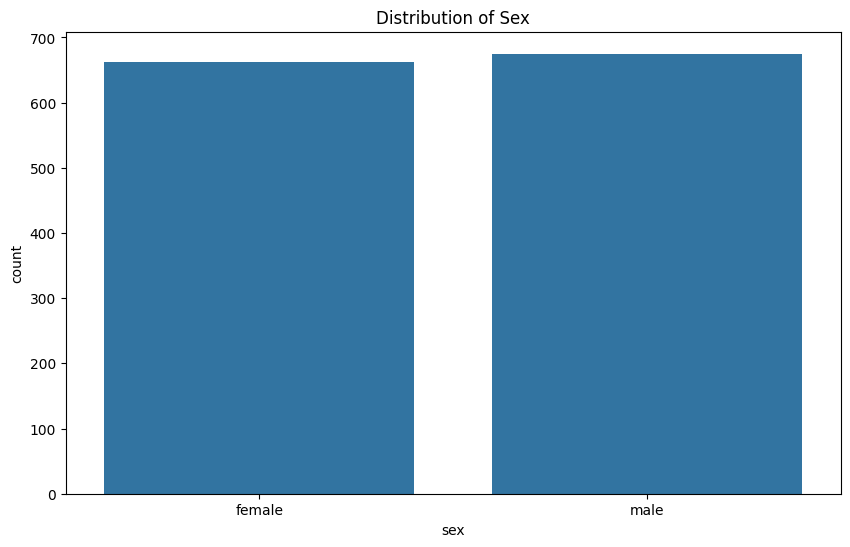

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x='sex', data=dataset)
plt.title('Distribution of Sex')
plt.show()

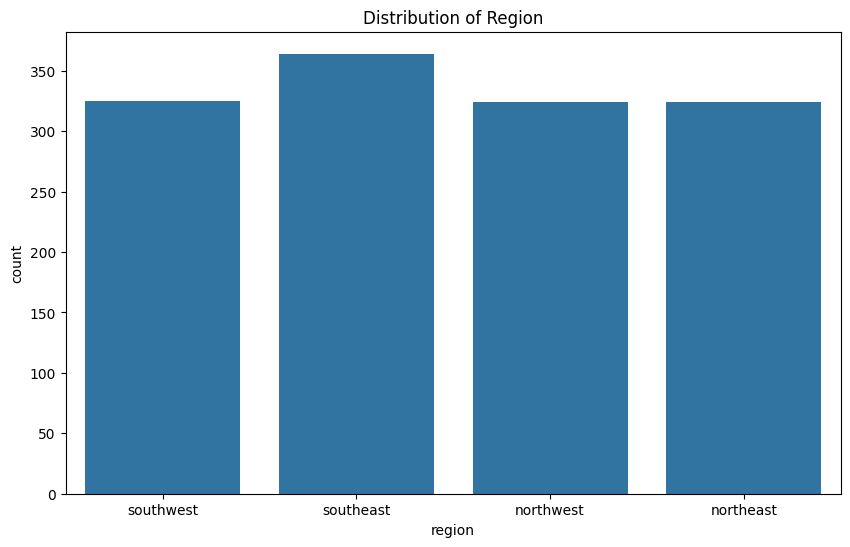

In [16]:
plt.figure(figsize=(10,6))
sns.countplot(x='region', data=dataset)
plt.title('Distribution of Region')
plt.show()

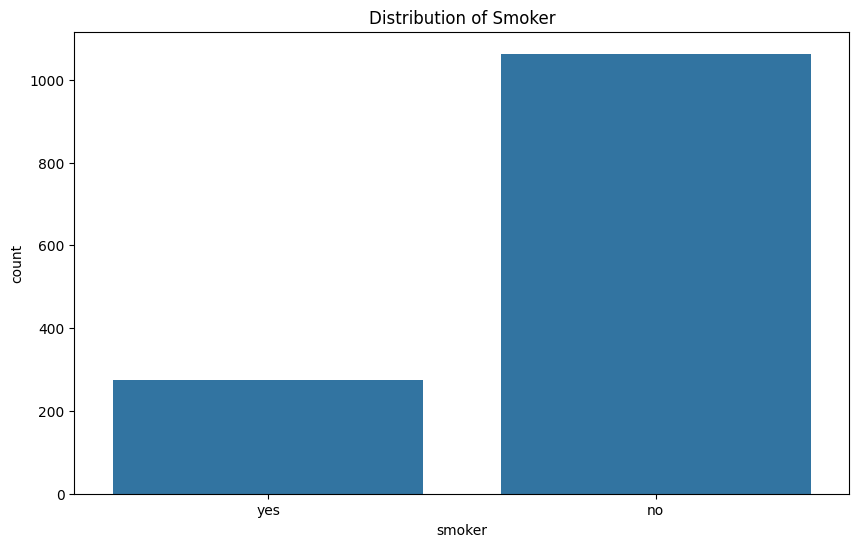

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x='smoker', data=dataset)
plt.title('Distribution of Smoker')
plt.show()

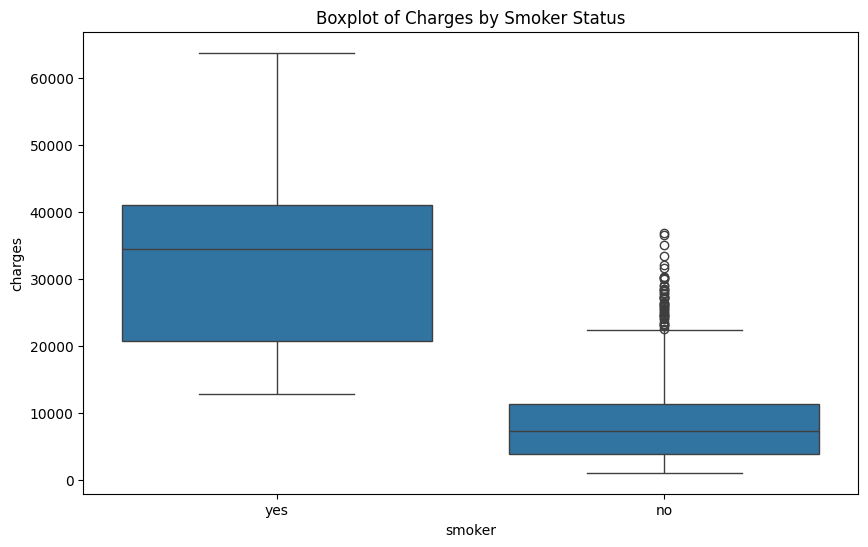

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='smoker', y='charges', data=dataset)
plt.title('Boxplot of Charges by Smoker Status')
plt.show()

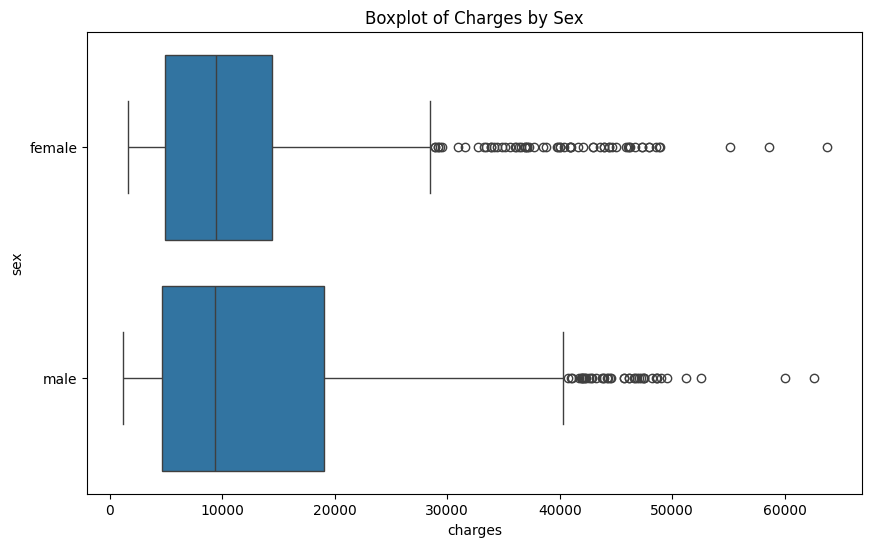

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x='charges', y='sex', data=dataset)
plt.title('Boxplot of Charges by Sex')
plt.show()

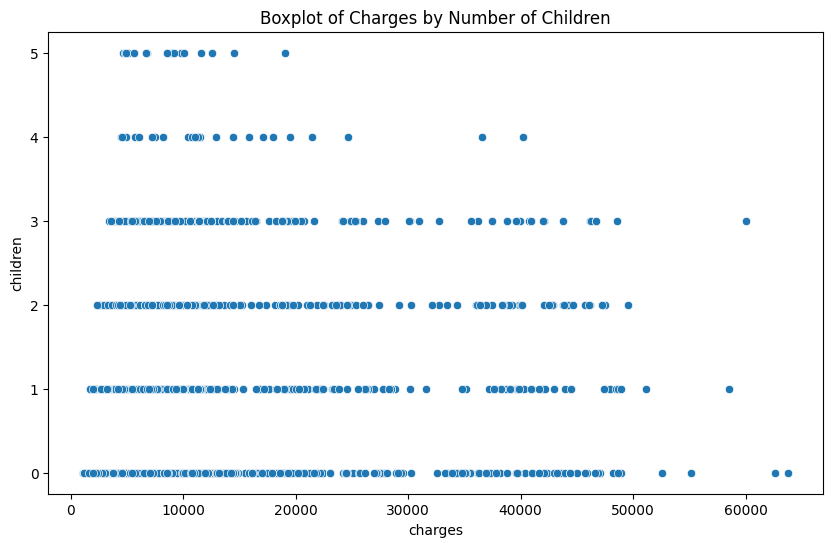

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='charges', y='children', data=dataset)
plt.title('Boxplot of Charges by Number of Children')
plt.show()

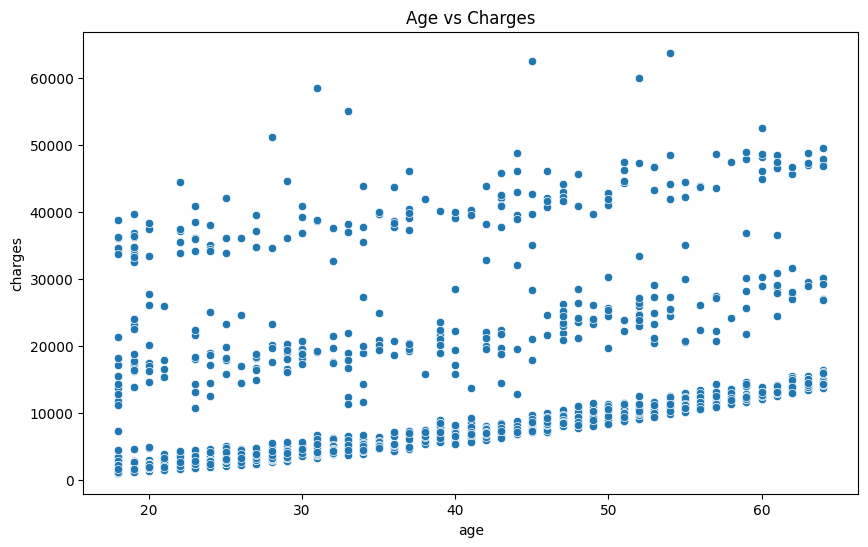

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='charges', data=dataset)
plt.title('Age vs Charges')
plt.show()

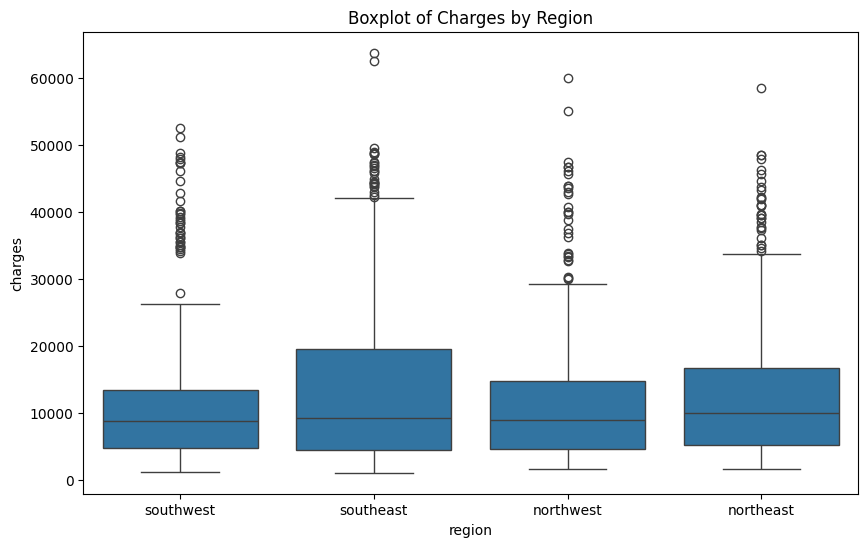

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x='region', y='charges', data=dataset)
plt.title('Boxplot of Charges by Region')
plt.show()  

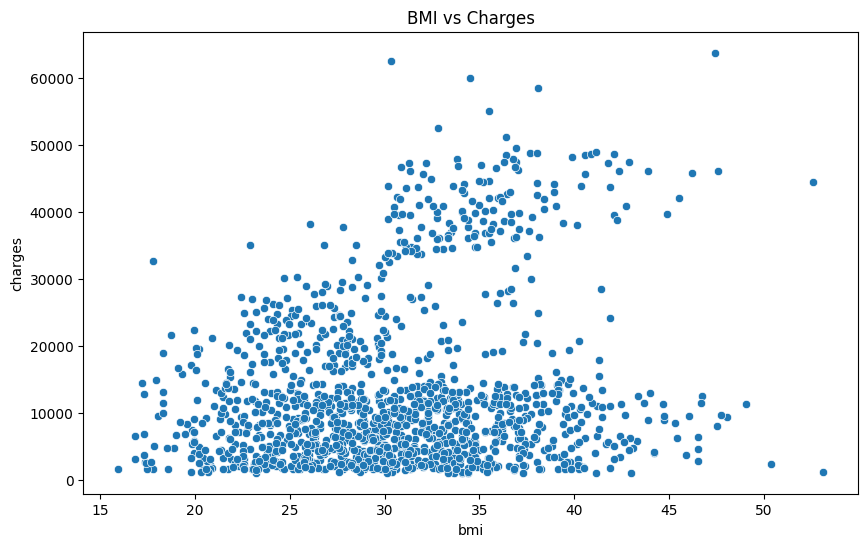

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='bmi', y='charges', data=dataset)
plt.title('BMI vs Charges')
plt.show()

## Encoding

In [24]:
df_encoded = dataset.copy()

df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['region'] = df_encoded['region'].astype('category').cat.codes

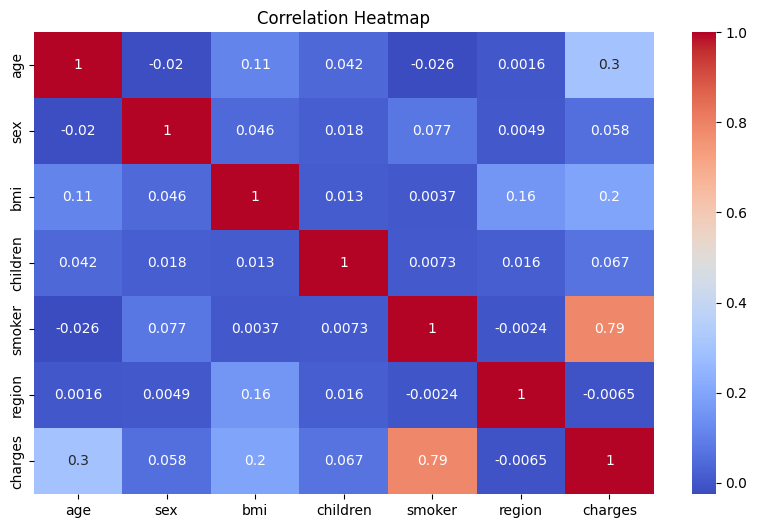

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [26]:
x = dataset.drop('charges', axis=1)
y = dataset['charges']

In [27]:
x.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [28]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [29]:
#One-hot encoding for categorical variables
x = pd.get_dummies(x, drop_first=True)

In [30]:
x.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [31]:
x.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   sex_male          1337 non-null   bool   
 4   smoker_yes        1337 non-null   bool   
 5   region_northwest  1337 non-null   bool   
 6   region_southeast  1337 non-null   bool   
 7   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(1), int64(2)
memory usage: 48.3 KB


## Train And Test Splite

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
print(x_test.shape)
print(y_test.shape)
print(x_train.shape)
print(y_train.shape)

(268, 8)
(268,)
(1069, 8)
(1069,)


## Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = lr.predict(x_test)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4177.045561036319
MSE: 35478020.67523559
RMSE: 5956.342894363587
R2 Score: 0.8069287081198012


In [39]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(10))

           Actual     Predicted
900    8688.85885   8143.693884
1064   5708.86700   5737.115683
1256  11436.73815  14369.314876
298   38746.35510  31745.513636
237    4463.20510   8962.386657
481    9304.70190  13149.722353
240   38511.62830  30446.760679
277    2150.46900   1453.288813
415    7345.72660  10633.018402
707   10264.44210  11318.943794


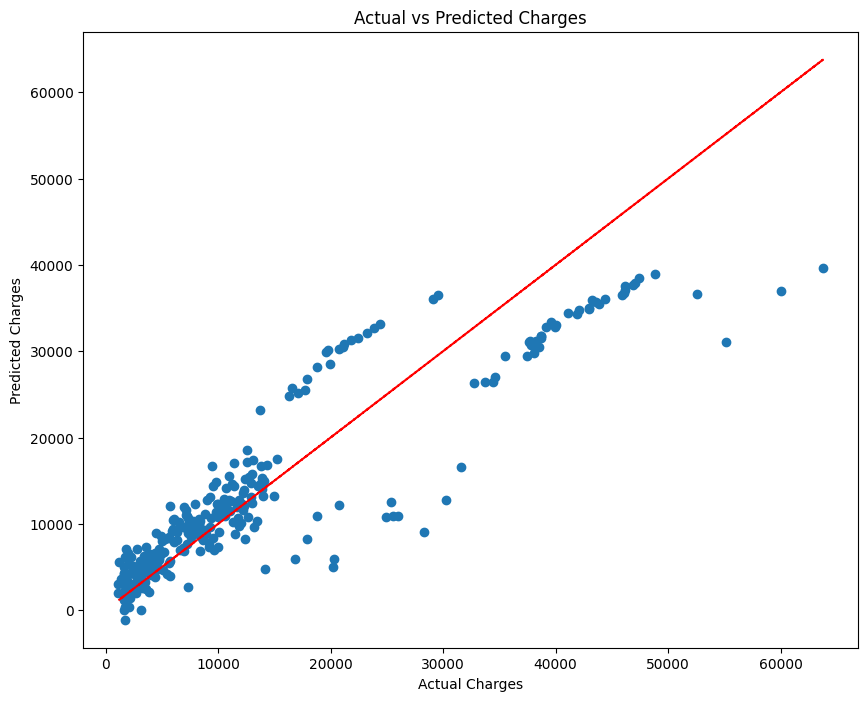

In [64]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred,)
plt.plot(y_test, y_test, 'r--') # Add a line for perfect predictions

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

## Decision Tree Regressor

In [41]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [42]:
y_pred_dt = dt.predict(x_test)

In [65]:
r2_dt = r2_score(y_test, y_pred_dt)
print("R2 Score for Decision Tree:", r2_dt)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)

print("MAE:", dt_mae)
print("MSE:", dt_mse)    
print("RMSE:", dt_rmse)

R2 Score for Decision Tree: 0.8188820336469307
MAE: 2730.629848988806
MSE: 33281524.624168295
RMSE: 5769.014181311075


## Random Forest Regressor

In [44]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [45]:
y_pred_rf  = rf.predict(x_test)

In [66]:
r2_rf = r2_score(y_test, y_pred_rf)
print("R2 Score for Random Forest:", r2_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

print("MAE:", rf_mae)
print("MSE:", rf_mse)    
print("RMSE:", rf_rmse)


R2 Score for Random Forest: 0.8796611113027272
MAE: 2637.9945481492537
MSE: 22113000.538090803
RMSE: 4702.4462291546515


## Model Comparison

In [48]:
module = pd.DataFrame({'Module': ['Linear Regression', 'Decision Tree', 'Random Forest'],
                        'R2 Score': [r2, r2_dt, r2_rf]})    
module

,Module,R2 Score
0,Linear Regression,0.806929
1,Decision Tree,0.818882
2,Random Forest,0.879661


## Feature Imprtance for the Random Forest

In [60]:
importance = pd.DataFrame({'Feature': x.columns, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
4,smoker_yes,0.600777
1,bmi,0.216088
0,age,0.135726
2,children,0.022938
3,sex_male,0.007076
5,region_northwest,0.006779
6,region_southeast,0.006045
7,region_southwest,0.004570


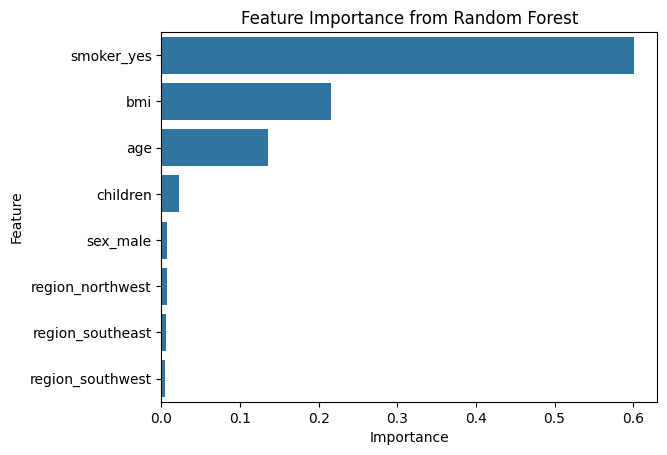

In [54]:
sns.barplot(x='Importance', y='Feature', data=importance.sort_values(by='Importance', ascending=False))
plt.title('Feature Importance from Random Forest')
plt.show()

## Sample testing 

In [50]:
sample_data = [[
    30,     # age
    25.5,   # bmi
    2,      # children
    1,      # sex_male
    0,      # smoker_yes
    0,      # region_northwest
    1,      # region_southeast
    0       # region_southwest
]]

prediction = rf.predict(sample_data)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: 5402.288677300003


c:\Users\vivek\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


# Conclusion

In [68]:
"""
The objective of predicting medical insurance charges was successfully achieved using Machine Learning techniques.

Different regression algorithms were tested, including Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

Among all models, Random Forest Regressor achieved the best performance with the highest R² score.

The project also identified smoking status as the most influential feature affecting insurance charges.
"""

'\nThe objective of predicting medical insurance charges was successfully achieved using Machine Learning techniques.\n\nDifferent regression algorithms were tested, including Linear Regression, Decision Tree Regressor, and Random Forest Regressor.\n\nAmong all models, Random Forest Regressor achieved the best performance with the highest R² score.\n\nThe project also identified smoking status as the most influential feature affecting insurance charges.\n'